# Raster EDA: Query Relevance Heatmap

Exploratory analysis of GeoTIFF rasters produced by `artifact_gen` dagspace.
Examines spatial distribution, score statistics, and overlay with source image locations.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import FancyArrowPatch
from pathlib import Path

import rasterio
from rasterio.plot import show as rio_show
from pyproj import Transformer

%matplotlib inline
plt.rcParams["figure.dpi"] = 150
plt.rcParams["figure.facecolor"] = "white"

In [2]:
# --- CONFIG: point at the raster output directory ---
RASTER_DIR = Path("/share/pierson/matt/mllmsci/outputs/raster/query_20260408_172719")

tif_path = next(RASTER_DIR.glob("*.tif"))
meta_path = next(RASTER_DIR.glob("*_metadata.json"))

with open(meta_path) as f:
    meta = json.load(f)

print(f"Query: {meta['query_text']}")
print(f"BBox:  {meta['bbox']}")
print(f"Grid:  {meta['grid_width']} x {meta['grid_height']} @ {meta['resolution_m']}m")
print(f"Points: {meta['n_input_points']}")
print(f"Interpolation: {meta['interpolation']}")
print(f"Score stats: {meta['score_stats']}")

Query: construction scaffolding
BBox:  [-73.99, 40.75, -73.98, 40.76]
Grid:  167 x 224 @ 5.0m
Points: 16676
Interpolation: {'method': 'rays', 'ray_length_m': 30.0, 'ray_decay': 'linear', 'normalize_by_count': False}
Score stats: {'raw_min': -0.30222225189208984, 'raw_max': 0.6300849914550781, 'raw_mean': 0.04136885702610016, 'raw_std': 0.14971959590911865}


## 1. Raster Overview

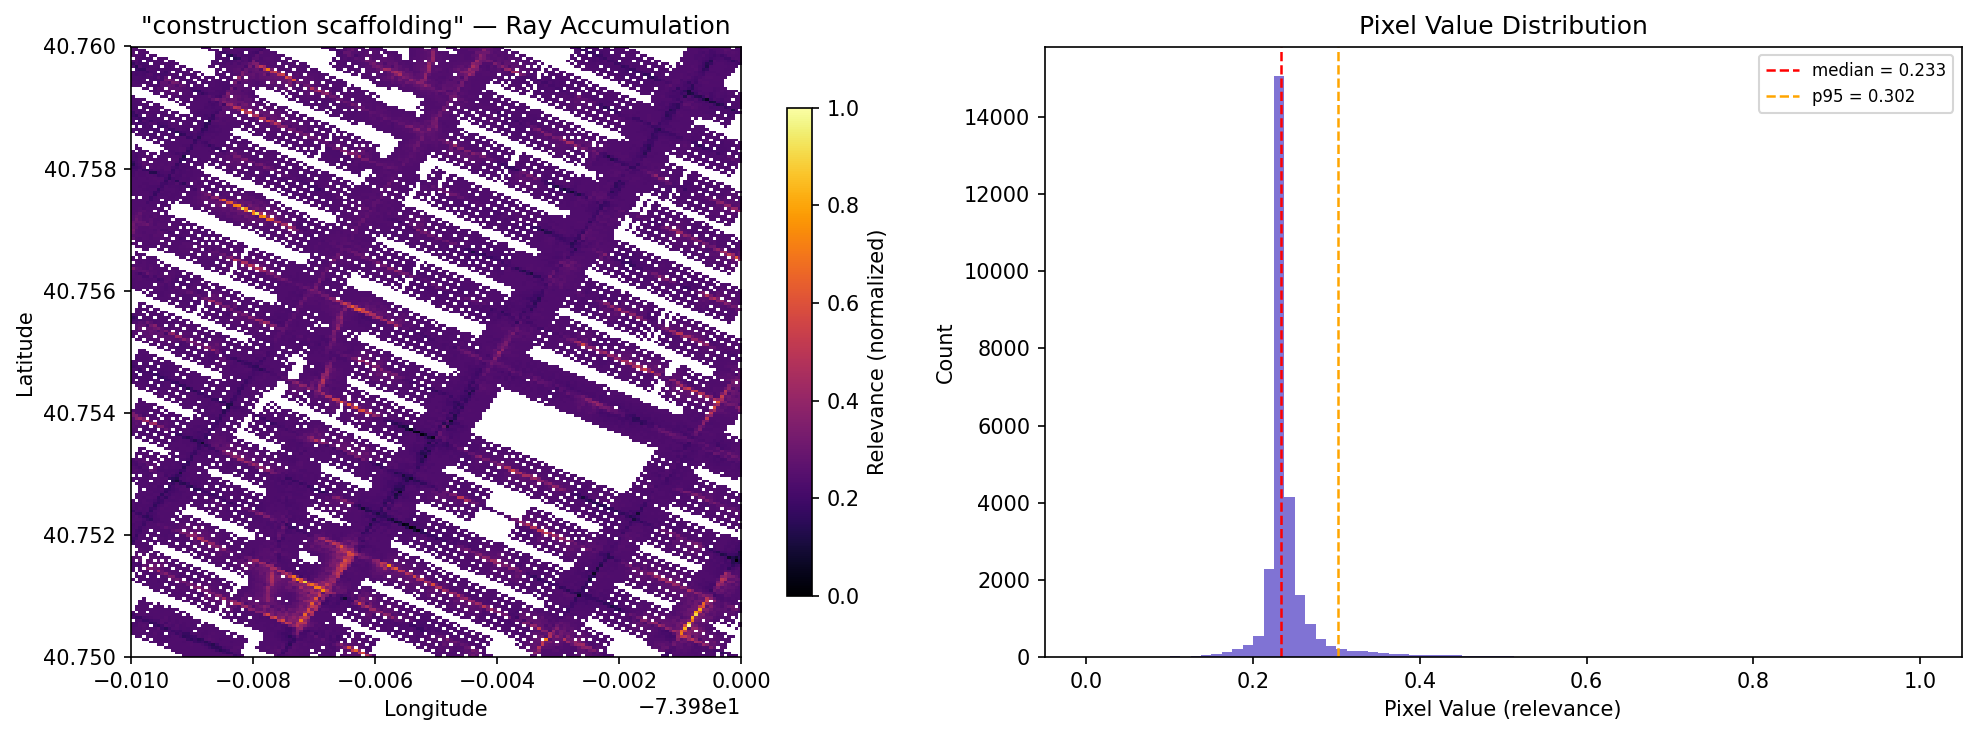

Coverage: 27625/37408 pixels (73.8%)
Mean: 0.2421, Std: 0.0442
p50: 0.2329, p95: 0.3023, p99: 0.4438


In [3]:
src = rasterio.open(tif_path)
data = src.read(1)
valid = data[~np.isnan(data)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raster heatmap
ax = axes[0]
im = ax.imshow(
    data,
    extent=[src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top],
    cmap="inferno",
    vmin=0, vmax=1,
    origin="upper",
    interpolation="nearest",
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f'"{meta["query_text"]}" — Ray Accumulation')
plt.colorbar(im, ax=ax, label="Relevance (normalized)", shrink=0.8)

# Right: histogram
ax = axes[1]
ax.hist(valid, bins=80, color="slateblue", edgecolor="none", alpha=0.85)
ax.axvline(np.median(valid), color="red", ls="--", lw=1.2, label=f"median = {np.median(valid):.3f}")
ax.axvline(np.percentile(valid, 95), color="orange", ls="--", lw=1.2, label=f"p95 = {np.percentile(valid, 95):.3f}")
ax.set_xlabel("Pixel Value (relevance)")
ax.set_ylabel("Count")
ax.set_title("Pixel Value Distribution")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

coverage = 100 * len(valid) / data.size
print(f"Coverage: {len(valid)}/{data.size} pixels ({coverage:.1f}%)")
print(f"Mean: {valid.mean():.4f}, Std: {valid.std():.4f}")
print(f"p50: {np.median(valid):.4f}, p95: {np.percentile(valid, 95):.4f}, p99: {np.percentile(valid, 99):.4f}")

## 2. Hotspot Detection

Identify contiguous high-relevance regions (above the 95th percentile) as candidate scaffolding locations.

In [4]:
from scipy import ndimage

threshold = np.percentile(valid, 95)
binary = (~np.isnan(data)) & (data >= threshold)
labeled, n_hotspots = ndimage.label(binary)

print(f"Threshold (p95): {threshold:.4f}")
print(f"Hotspot regions: {n_hotspots}")

# Compute hotspot properties
hotspot_stats = []
for label_id in range(1, n_hotspots + 1):
    mask = labeled == label_id
    region_vals = data[mask]
    rows, cols = np.where(mask)
    # Convert pixel center to geographic coords
    center_col = cols.mean()
    center_row = rows.mean()
    lon = src.bounds.left + (center_col + 0.5) * src.res[0]
    lat = src.bounds.top - (center_row + 0.5) * src.res[1]
    hotspot_stats.append({
        "label": label_id,
        "n_pixels": int(mask.sum()),
        "area_m2": int(mask.sum()) * meta["resolution_m"] ** 2,
        "max_value": float(region_vals.max()),
        "mean_value": float(region_vals.mean()),
        "center_lon": lon,
        "center_lat": lat,
    })

df_hotspots = pd.DataFrame(hotspot_stats).sort_values("max_value", ascending=False)
print(f"\nTop 10 hotspots by max value:")
df_hotspots.head(10)

Threshold (p95): 0.3023
Hotspot regions: 364

Top 10 hotspots by max value:


,label,n_pixels,area_m2,max_value,mean_value,center_lon,center_lat
317,318,71,1775.0,1.000000,0.445522,-73.980770,40.750624
88,89,20,500.0,0.988869,0.644197,-73.988057,40.757306
271,272,263,6575.0,0.897381,0.408796,-73.987058,40.751170
286,287,14,350.0,0.760972,0.451316,-73.985864,40.751511
2,3,14,350.0,0.713861,0.446644,-73.987772,40.759630
350,351,5,125.0,0.705202,0.474096,-73.983216,40.750246
37,38,17,425.0,0.686235,0.414193,-73.988230,40.758988
140,141,27,675.0,0.665701,0.447708,-73.986271,40.755690
86,87,2,50.0,0.663782,0.576631,-73.988503,40.757478
357,358,8,200.0,0.645159,0.492678,-73.986340,40.750117


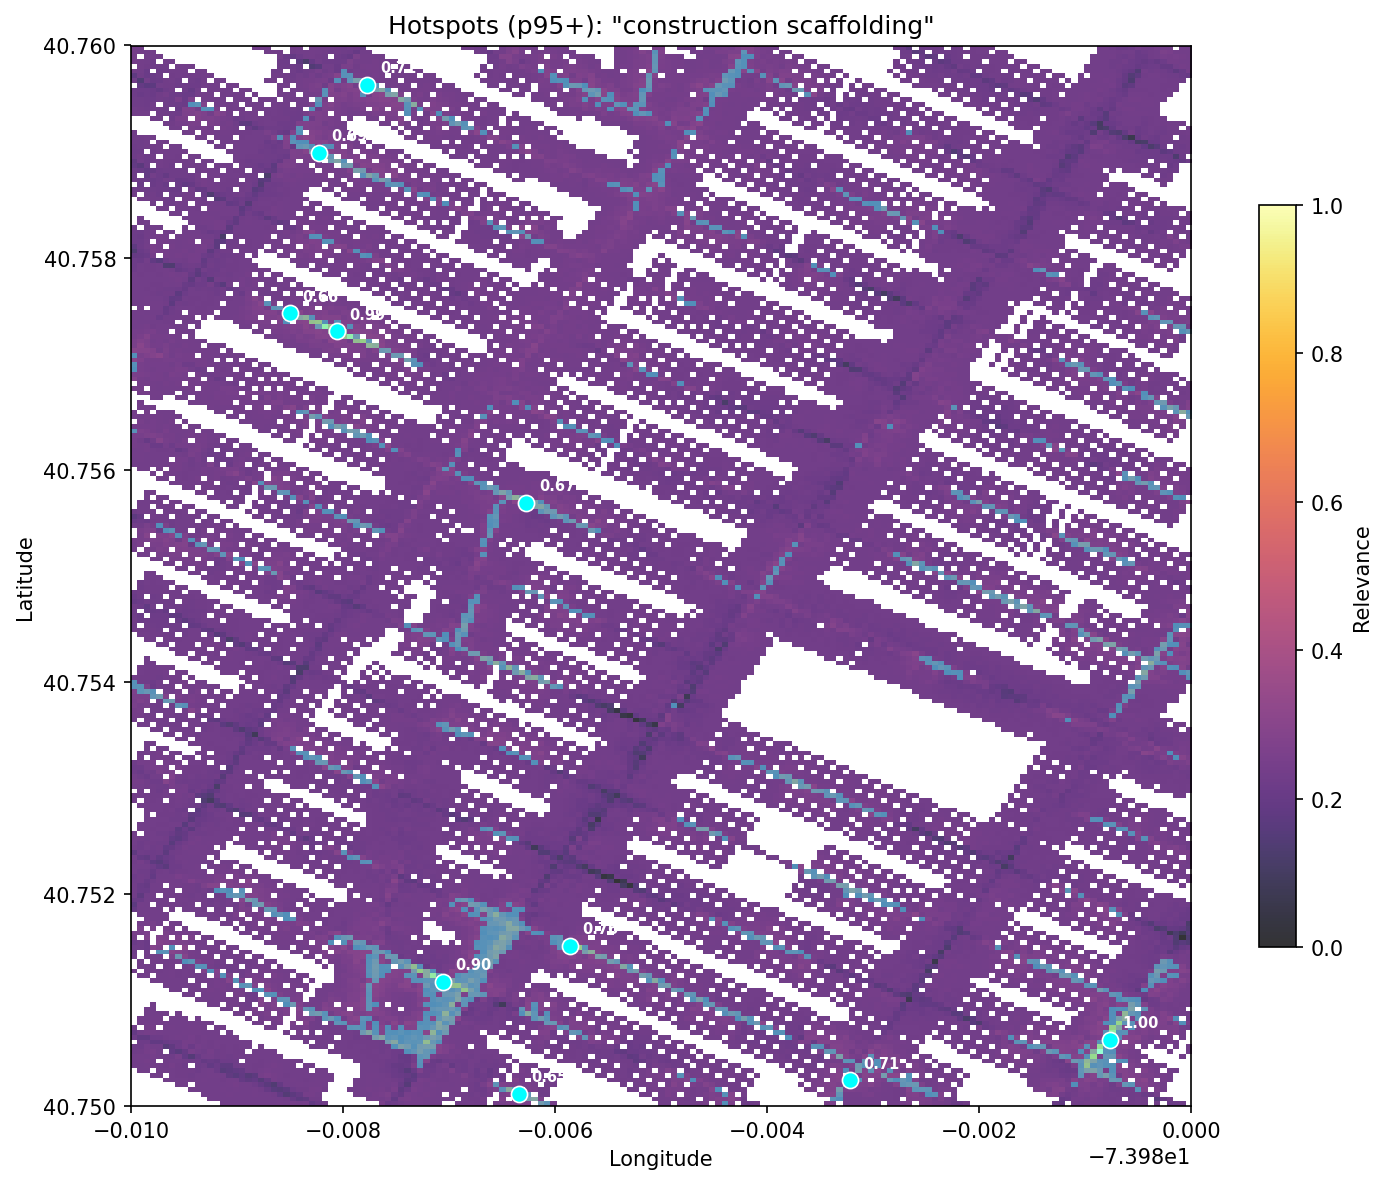

In [5]:
# Hotspot map with labeled regions
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    data,
    extent=[src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top],
    cmap="inferno",
    vmin=0, vmax=1,
    origin="upper",
    interpolation="nearest",
    alpha=0.8,
)

# Overlay hotspot contours
hotspot_overlay = np.where(binary, 1.0, np.nan)
ax.imshow(
    hotspot_overlay,
    extent=[src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top],
    cmap=mcolors.ListedColormap(["cyan"]),
    origin="upper",
    interpolation="nearest",
    alpha=0.4,
)

# Mark top 10 hotspot centers
top = df_hotspots.head(10)
ax.scatter(
    top["center_lon"], top["center_lat"],
    c="cyan", s=60, edgecolors="white", linewidths=0.8, zorder=5,
)
for _, row in top.iterrows():
    ax.annotate(
        f'{row["max_value"]:.2f}',
        (row["center_lon"], row["center_lat"]),
        textcoords="offset points", xytext=(6, 6),
        fontsize=7, color="white", fontweight="bold",
    )

plt.colorbar(im, ax=ax, label="Relevance", shrink=0.7)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f'Hotspots (p95+): "{meta["query_text"]}"')
plt.tight_layout()
plt.show()

## 3. Ray Coverage & Source Points

Overlay camera positions and their ray directions on the raster to visualize how evidence accumulates.

In [6]:
# Load source embeddings for this bbox to get camera positions + bearings
import pyarrow.parquet as pq
from pathlib import Path as _Path

EMBED_DIR = meta.get("embeddings_input_path",
    "/share/pierson/matt/mllmsci/outputs/embed/cyclomedia_20260407_060223")
bbox = meta["bbox"]
west, south, east, north = bbox

FACE_BEARING_DEG = {"F": 0.0, "R": 90.0, "B": 180.0, "L": 270.0}

# Load just the columns we need
parts = sorted(_Path(EMBED_DIR).glob("part-*.parquet"))
cols = ["lat", "lon", "face", "recorderDirection", "yawDegrees"]
dfs = []
for p in parts:
    schema_cols = set(pq.read_schema(p).names)
    read_cols = [c for c in cols if c in schema_cols]
    df_part = pd.read_parquet(p, columns=read_cols)
    mask = (
        df_part["lat"].notna() & df_part["lon"].notna()
        & (df_part["lon"] >= west) & (df_part["lon"] <= east)
        & (df_part["lat"] >= south) & (df_part["lat"] <= north)
    )
    dfs.append(df_part[mask])
    del df_part

df_points = pd.concat(dfs, ignore_index=True)
del dfs

# Compute bearing
yaw_col = "recorderDirection" if "recorderDirection" in df_points.columns else "yawDegrees"
yaw = df_points[yaw_col].values.astype(float)
if np.nanmedian(np.abs(yaw)) < 7.0:
    yaw = np.degrees(yaw)
offsets = df_points["face"].map(FACE_BEARING_DEG).values.astype(float)
df_points["bearing"] = (yaw + offsets) % 360

print(f"Loaded {len(df_points)} camera images in bbox")
df_points.head()

Loaded 16676 camera images in bbox


,lat,lon,face,recorderDirection,yawDegrees,bearing
0,40.752151,-73.981669,F,-151.818783,0.744845,208.181217
1,40.752151,-73.981669,L,-151.818783,0.744845,118.181217
2,40.752151,-73.981669,R,-151.818783,0.744845,298.181217
3,40.752151,-73.981669,B,-151.818783,0.744845,28.181217
4,40.753132,-73.984007,F,-62.221855,20626.079554,297.778145


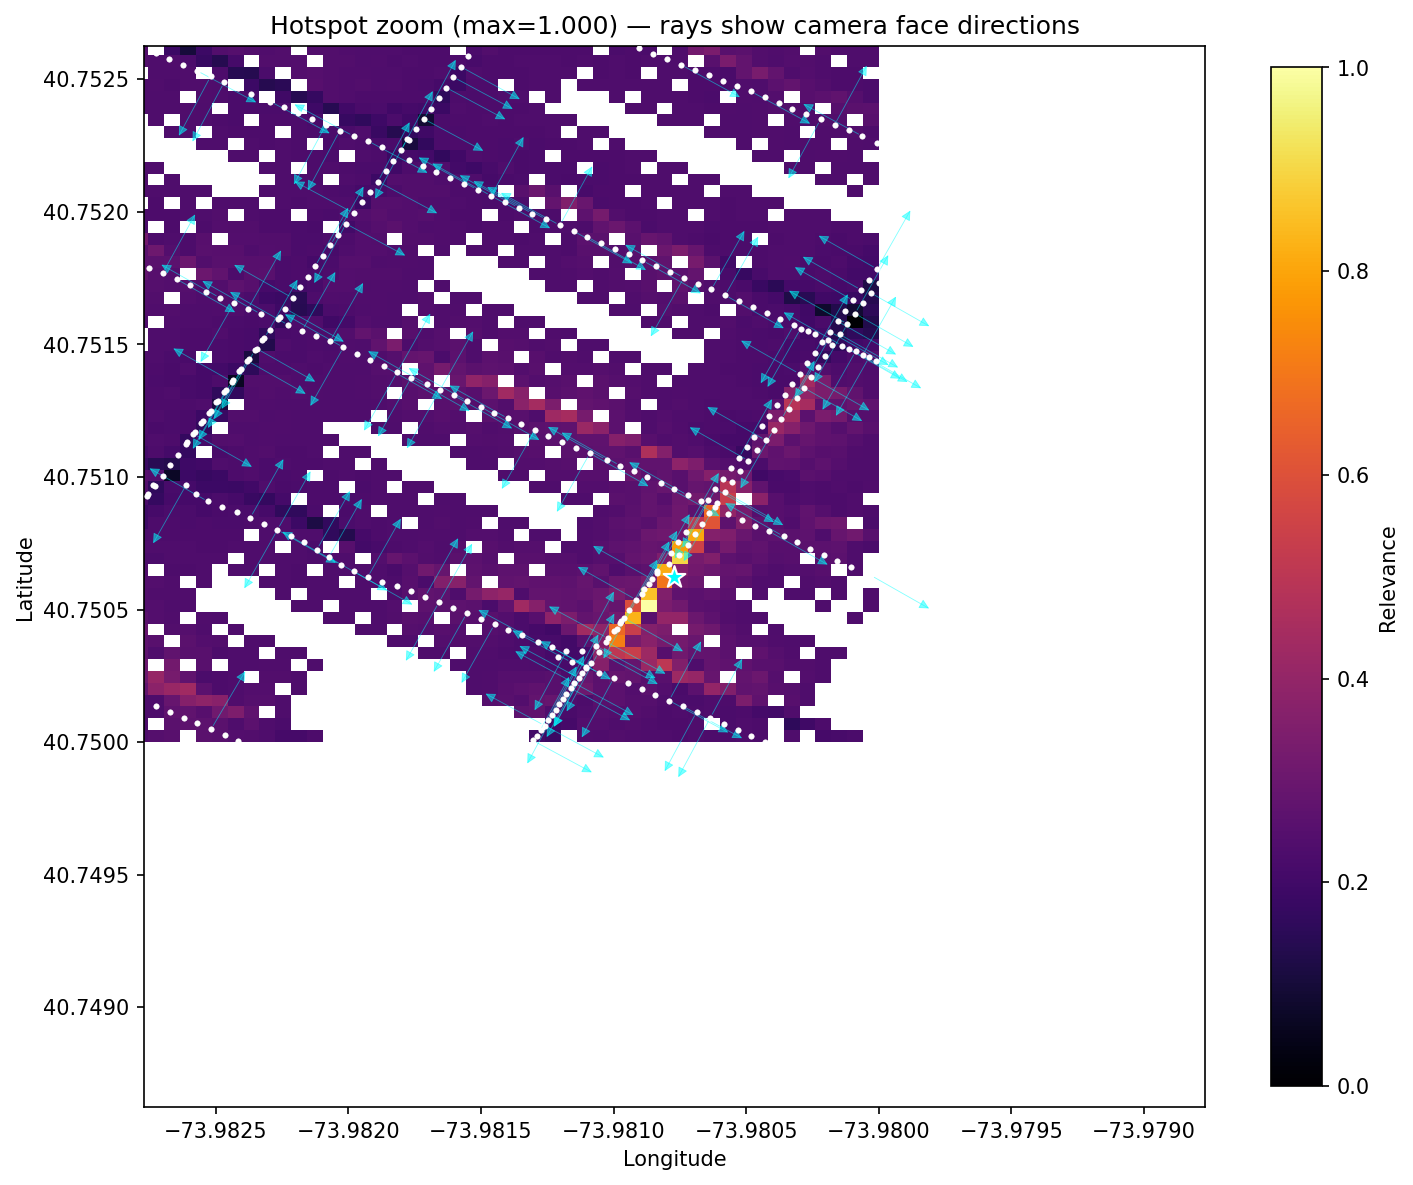

Cameras in view: 1296
Hotspot center: (40.750624, -73.980770)
Hotspot area: 1775 m^2


In [7]:
# Zoom into the highest-scoring hotspot with ray arrows
if len(df_hotspots) == 0:
    print("No hotspots found")
else:
    top_hotspot = df_hotspots.iloc[0]
    cx, cy = top_hotspot["center_lon"], top_hotspot["center_lat"]
    pad = 0.002  # ~200m pad around hotspot center

    fig, ax = plt.subplots(figsize=(10, 10))

    im = ax.imshow(
        data,
        extent=[src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top],
        cmap="inferno",
        vmin=0, vmax=1,
        origin="upper",
        interpolation="nearest",
    )

    # Filter cameras near this hotspot
    nearby = df_points[
        (df_points["lon"].between(cx - pad, cx + pad))
        & (df_points["lat"].between(cy - pad, cy + pad))
    ].copy()

    # Draw ray arrows (subsample if too many)
    draw_df = nearby.sample(n=min(200, len(nearby)), random_state=42) if len(nearby) > 200 else nearby
    ray_len_deg = 30.0 / 111320  # ~30m in degrees (approximate)

    for _, row in draw_df.iterrows():
        bearing_rad = np.radians(row["bearing"])
        dx = np.sin(bearing_rad) * ray_len_deg
        dy = np.cos(bearing_rad) * ray_len_deg
        ax.annotate(
            "", xy=(row["lon"] + dx, row["lat"] + dy),
            xytext=(row["lon"], row["lat"]),
            arrowprops=dict(arrowstyle="-|>", color="cyan", lw=0.4, alpha=0.5),
        )

    ax.scatter(nearby["lon"], nearby["lat"], s=3, c="white", alpha=0.6, zorder=4)
    ax.scatter([cx], [cy], s=120, marker="*", c="cyan", edgecolors="white", linewidths=1, zorder=5)

    ax.set_xlim(cx - pad, cx + pad)
    ax.set_ylim(cy - pad, cy + pad)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"Hotspot zoom (max={top_hotspot['max_value']:.3f}) — rays show camera face directions")
    plt.colorbar(im, ax=ax, label="Relevance", shrink=0.7)
    plt.tight_layout()
    plt.show()

    print(f"Cameras in view: {len(nearby)}")
    print(f"Hotspot center: ({cy:.6f}, {cx:.6f})")
    print(f"Hotspot area: {top_hotspot['area_m2']:.0f} m^2")

## 4. Cross-Section Profiles

Slice the raster along longitude (E-W) and latitude (N-S) through the top hotspot to see the spatial falloff of relevance.

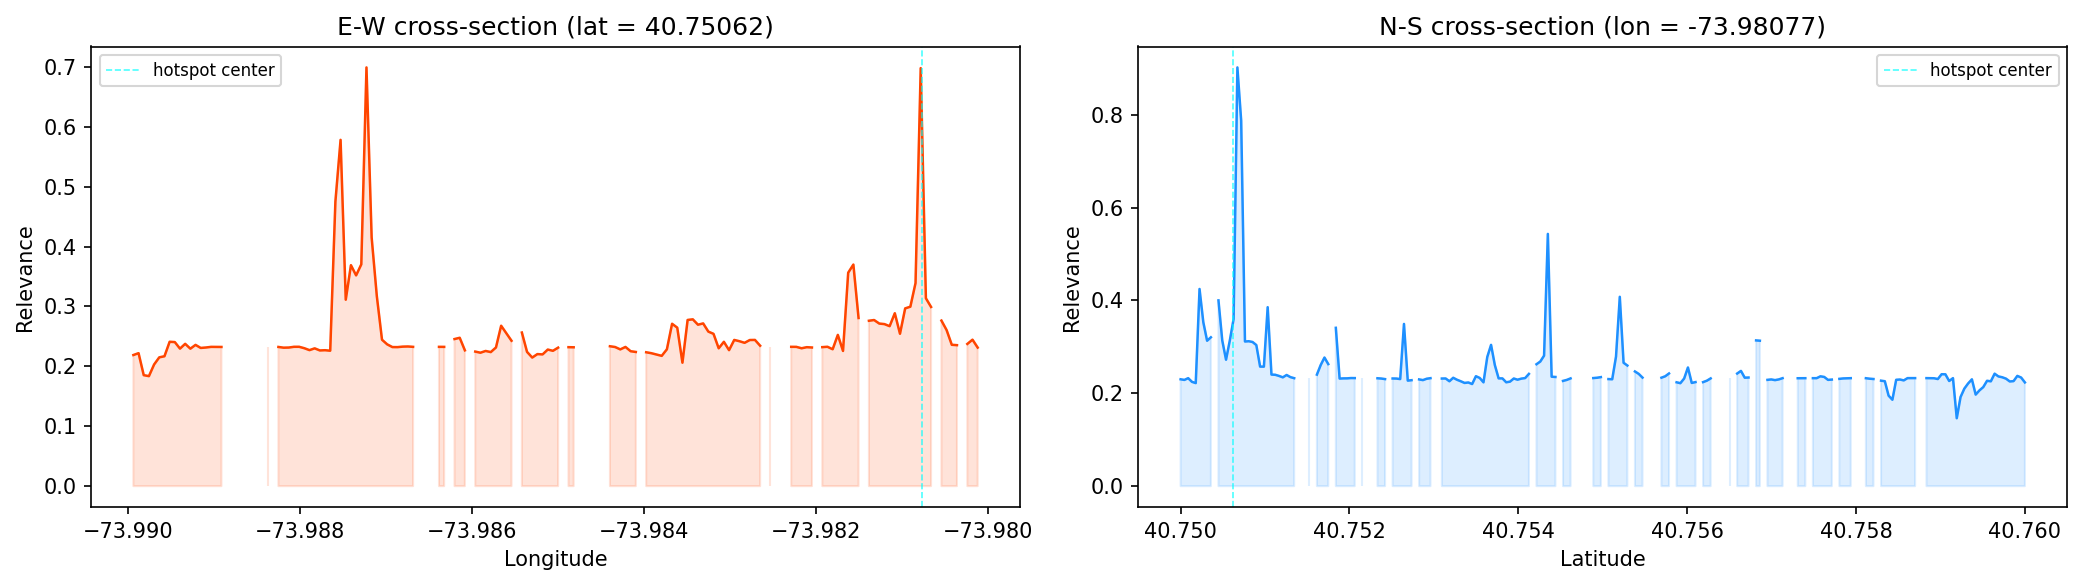

In [8]:
if len(df_hotspots) > 0:
    top_hotspot = df_hotspots.iloc[0]
    cx, cy = top_hotspot["center_lon"], top_hotspot["center_lat"]

    # Convert hotspot center to pixel coords
    col_center = int((cx - src.bounds.left) / src.res[0])
    row_center = int((src.bounds.top - cy) / abs(src.res[1]))
    col_center = np.clip(col_center, 0, data.shape[1] - 1)
    row_center = np.clip(row_center, 0, data.shape[0] - 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # E-W slice (fixed row)
    ax = axes[0]
    ew_slice = data[row_center, :]
    lons = np.linspace(src.bounds.left, src.bounds.right, data.shape[1])
    ax.plot(lons, ew_slice, color="orangered", lw=1.2)
    ax.axvline(cx, color="cyan", ls="--", lw=0.8, alpha=0.7, label="hotspot center")
    ax.fill_between(lons, ew_slice, alpha=0.15, color="orangered")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Relevance")
    ax.set_title(f"E-W cross-section (lat = {cy:.5f})")
    ax.legend(fontsize=8)

    # N-S slice (fixed col)
    ax = axes[1]
    ns_slice = data[:, col_center]
    lats = np.linspace(src.bounds.top, src.bounds.bottom, data.shape[0])
    ax.plot(lats, ns_slice, color="dodgerblue", lw=1.2)
    ax.axvline(cy, color="cyan", ls="--", lw=0.8, alpha=0.7, label="hotspot center")
    ax.fill_between(lats, ns_slice, alpha=0.15, color="dodgerblue")
    ax.set_xlabel("Latitude")
    ax.set_ylabel("Relevance")
    ax.set_title(f"N-S cross-section (lon = {cx:.5f})")
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

## 5. Face Direction Breakdown

How do scores differ by face direction? Helps assess whether certain orientations contribute more signal.

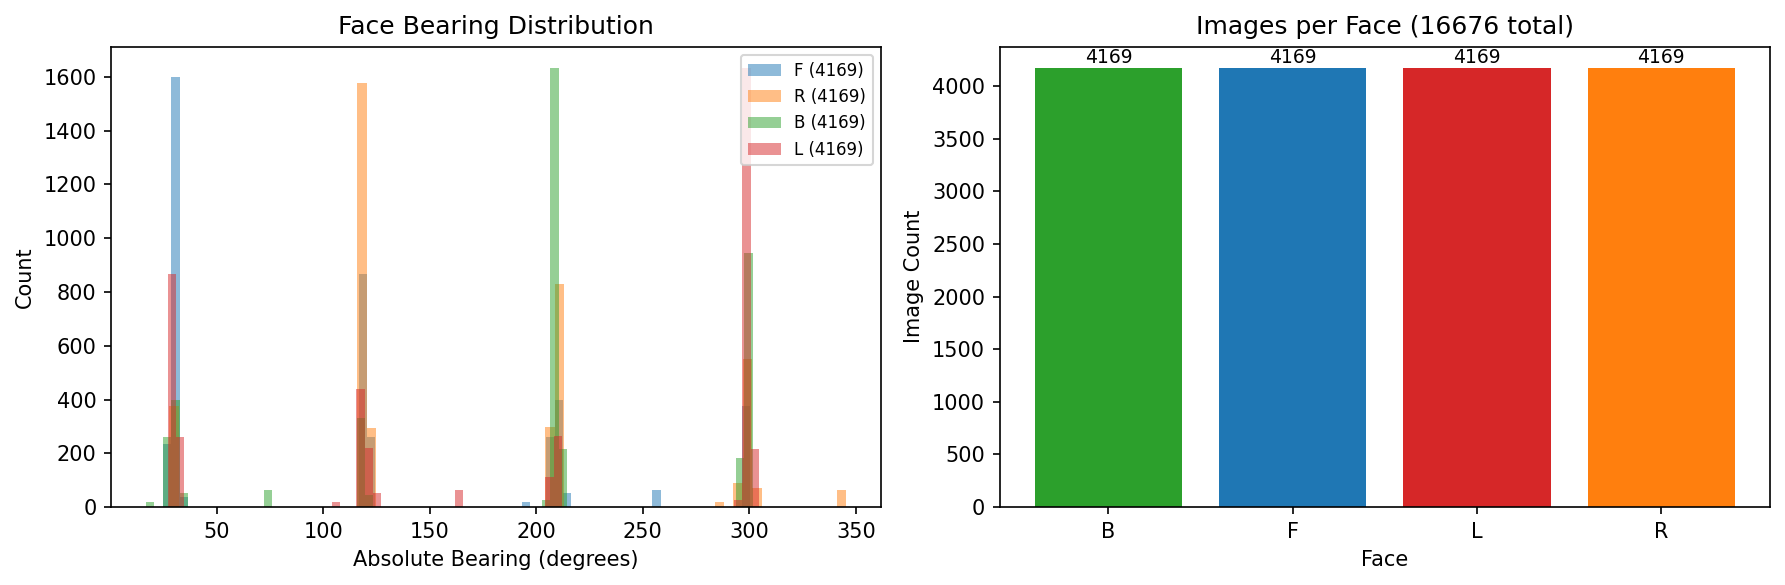

In [9]:
# Reload scores alongside face metadata (need embeddings for this)
# We'll use the metadata sidecar score stats instead of recomputing
# For face breakdown, show bearing distribution by face

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bearing distribution by face
ax = axes[0]
face_colors = {"F": "tab:blue", "R": "tab:orange", "B": "tab:green", "L": "tab:red"}
for face, color in face_colors.items():
    subset = df_points[df_points["face"] == face]
    ax.hist(subset["bearing"], bins=72, alpha=0.5, color=color, label=f"{face} ({len(subset)})")
ax.set_xlabel("Absolute Bearing (degrees)")
ax.set_ylabel("Count")
ax.set_title("Face Bearing Distribution")
ax.legend(fontsize=8)

# Face counts
ax = axes[1]
face_counts = df_points["face"].value_counts().sort_index()
bars = ax.bar(face_counts.index, face_counts.values, color=[face_colors.get(f, "gray") for f in face_counts.index])
ax.set_xlabel("Face")
ax.set_ylabel("Image Count")
ax.set_title(f"Images per Face ({len(df_points)} total)")
for bar, val in zip(bars, face_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            str(val), ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## 6. Coverage Heatmap (Ray Count)

Visualize how many rays pass through each cell — independent of score. Shows observation density.

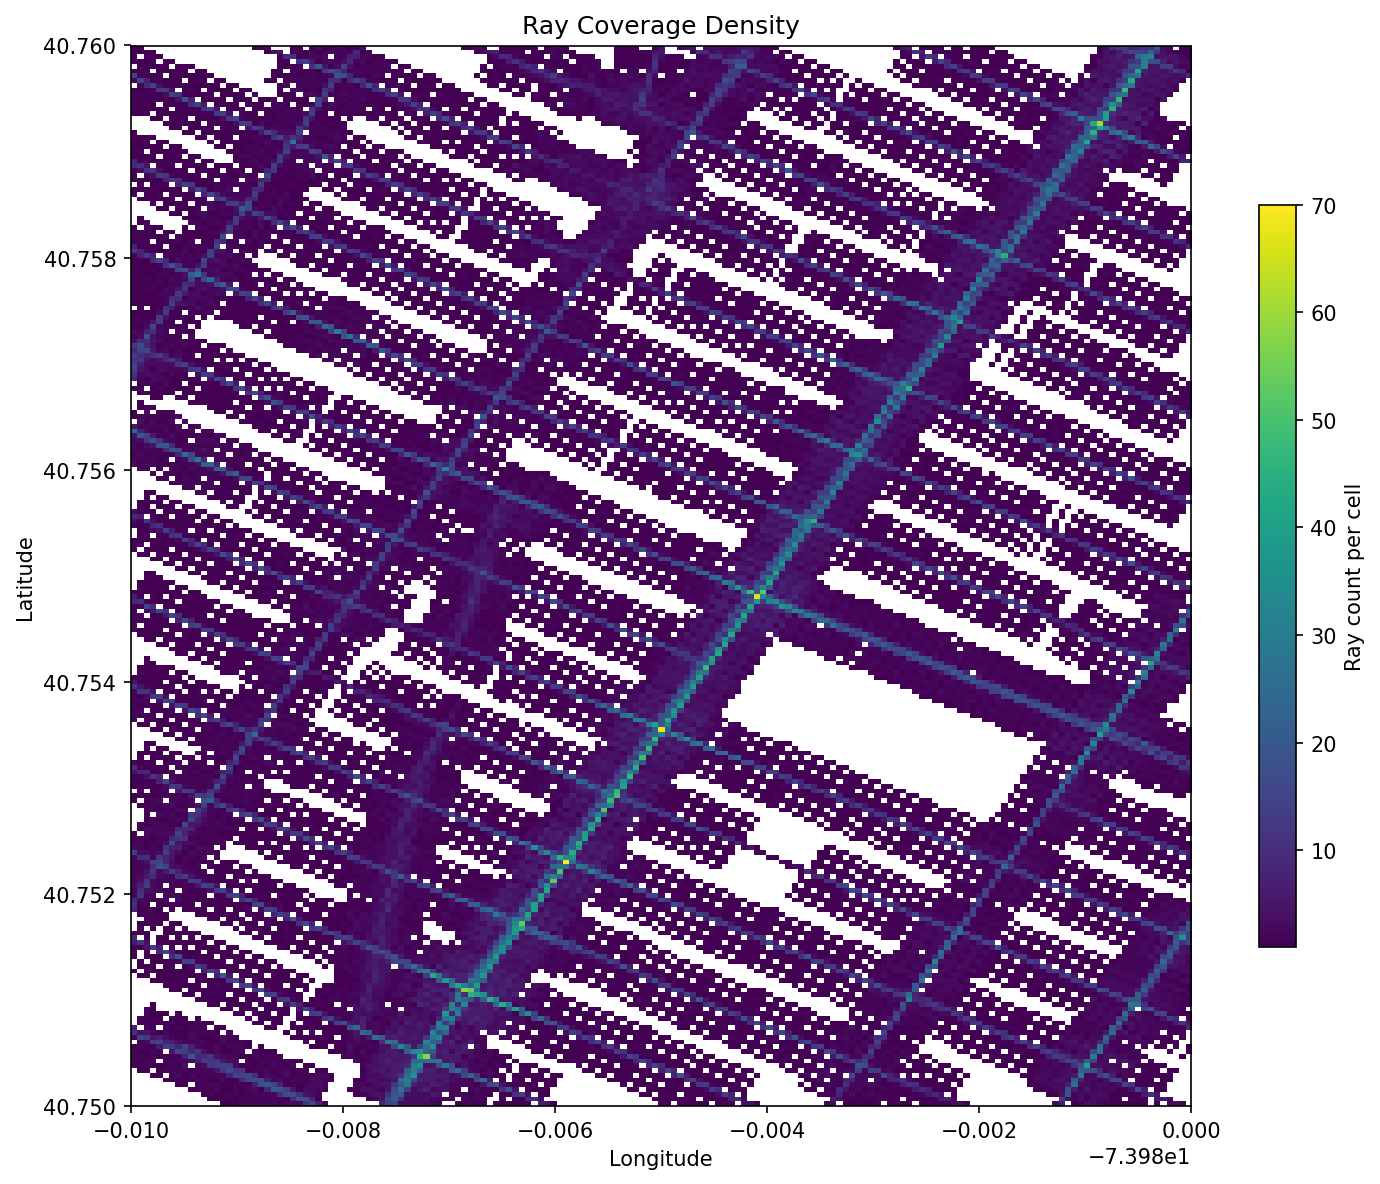

Cells with coverage: 27625/37408 (73.8%)
Ray count: mean=3.7, max=70


In [10]:
# Recompute ray counts (lightweight — no embeddings needed)
from dagspaces.artifact_gen.stages.raster import _bresenham_line

to_proj = Transformer.from_crs("EPSG:4326", meta["working_crs"], always_xy=True)
proj_bbox_w, proj_bbox_s = to_proj.transform(west, south)
proj_bbox_e, proj_bbox_n = to_proj.transform(east, north)

res = meta["resolution_m"]
width, height = meta["grid_width"], meta["grid_height"]

ray_count = np.zeros((height, width), dtype=np.int32)
ray_length_m = meta["interpolation"].get("ray_length_m", 30.0)

px, py = to_proj.transform(df_points["lon"].values, df_points["lat"].values)
bearings_rad = np.radians(df_points["bearing"].values)
dx = np.sin(bearings_rad) * ray_length_m
dy = np.cos(bearings_rad) * ray_length_m

for i in range(len(df_points)):
    if not np.isfinite(bearings_rad[i]):
        continue
    c0 = int((px[i] - proj_bbox_w) / res)
    r0 = int((proj_bbox_n - py[i]) / res)
    c1 = int((px[i] + dx[i] - proj_bbox_w) / res)
    r1 = int((proj_bbox_n - py[i] - dy[i]) / res)

    if (c0 < 0 and c1 < 0) or (c0 >= width and c1 >= width):
        continue
    if (r0 < 0 and r1 < 0) or (r0 >= height and r1 >= height):
        continue

    rows, cols = _bresenham_line(r0, c0, r1, c1)
    in_bounds = (rows >= 0) & (rows < height) & (cols >= 0) & (cols < width)
    rows, cols = rows[in_bounds], cols[in_bounds]
    if len(rows) > 0:
        np.add.at(ray_count, (rows, cols), 1)

fig, ax = plt.subplots(figsize=(10, 8))
rc_plot = np.where(ray_count > 0, ray_count, np.nan).astype(float)
im = ax.imshow(
    rc_plot,
    extent=[src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top],
    cmap="viridis",
    origin="upper",
    interpolation="nearest",
)
plt.colorbar(im, ax=ax, label="Ray count per cell", shrink=0.7)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Ray Coverage Density")
plt.tight_layout()
plt.show()

covered = np.sum(ray_count > 0)
print(f"Cells with coverage: {covered}/{ray_count.size} ({100*covered/ray_count.size:.1f}%)")
print(f"Ray count: mean={ray_count[ray_count > 0].mean():.1f}, max={ray_count.max()}")

## 7. Relevance vs. Coverage Scatter

Does high relevance correlate with high ray count? If so, hotspots may just reflect observation density rather than true signal.

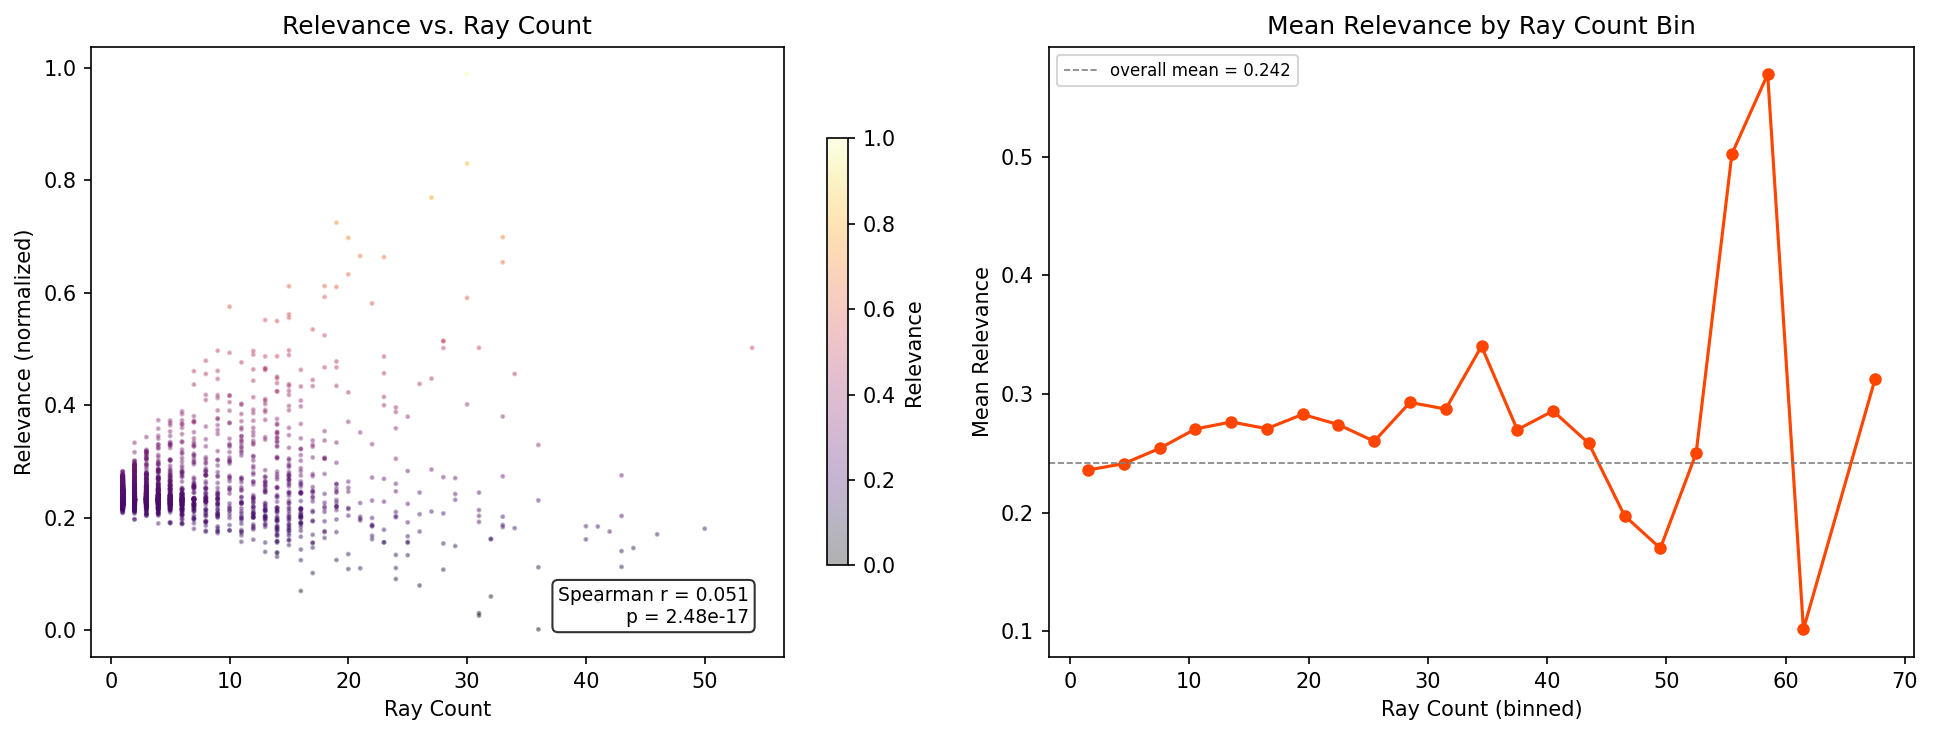

In [11]:
flat_data = data.ravel()
flat_count = ray_count.ravel().astype(float)

# Only cells with coverage
mask = flat_count > 0
vals = flat_data[mask]
counts = flat_count[mask]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter (subsample for readability)
ax = axes[0]
n_sample = min(5000, len(vals))
idx = np.random.default_rng(42).choice(len(vals), n_sample, replace=False)
sc = ax.scatter(counts[idx], vals[idx], s=2, alpha=0.3, c=vals[idx], cmap="inferno", vmin=0, vmax=1)
ax.set_xlabel("Ray Count")
ax.set_ylabel("Relevance (normalized)")
ax.set_title("Relevance vs. Ray Count")
plt.colorbar(sc, ax=ax, label="Relevance", shrink=0.7)

# Correlation
from scipy.stats import spearmanr
rho, pval = spearmanr(counts, vals)
ax.text(0.95, 0.05, f"Spearman r = {rho:.3f}\np = {pval:.2e}",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))

# Binned mean
ax = axes[1]
count_bins = np.arange(0, counts.max() + 2, max(1, int(counts.max() / 20)))
bin_means = []
bin_centers = []
for i in range(len(count_bins) - 1):
    in_bin = (counts >= count_bins[i]) & (counts < count_bins[i + 1])
    if in_bin.sum() > 0:
        bin_means.append(vals[in_bin].mean())
        bin_centers.append((count_bins[i] + count_bins[i + 1]) / 2)
ax.plot(bin_centers, bin_means, "o-", color="orangered", markersize=5)
ax.set_xlabel("Ray Count (binned)")
ax.set_ylabel("Mean Relevance")
ax.set_title("Mean Relevance by Ray Count Bin")
ax.axhline(vals.mean(), color="gray", ls="--", lw=0.8, label=f"overall mean = {vals.mean():.3f}")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [12]:
src.close()
print("Single-query analysis complete.")

Single-query analysis complete.


---

# Green vs. White Scaffolding: Citywide Comparison

Two citywide rasters generated with `qwen_raw` mode (native 4096-dim embeddings, no PCA):
- **Green scaffolding** — standard construction scaffolding with green mesh/netting
- **White scaffolding** — ornamental/fancy scaffolding with white arched elements

The `combine` stage produces:
- `signed_diff` = green - white (positive = green dominates, negative = white dominates)
- `abs_diff` = |green - white| (classification confidence — high when one type clearly dominates)

In [13]:
# --- CONFIG: point at the scaffolding pipeline outputs ---
GREEN_DIR = Path("/share/pierson/matt/mllmsci/outputs/raster/green_scaffolding_20260408_175952")
WHITE_DIR = Path("/share/pierson/matt/mllmsci/outputs/raster/white_scaffolding_20260408_175952")
COMBINE_DIR = Path("/share/pierson/matt/mllmsci/outputs/raster/scaffolding_combined_20260408_175952")

# Load all rasters
src_green = rasterio.open(next(GREEN_DIR.glob("*.tif")))
src_white = rasterio.open(next(WHITE_DIR.glob("*.tif")))
src_signed = rasterio.open(COMBINE_DIR / "scaffolding_types_signed_diff.tif")
src_abs = rasterio.open(COMBINE_DIR / "scaffolding_types_abs_diff.tif")

green = src_green.read(1)
white = src_white.read(1)
signed_diff = src_signed.read(1)
abs_diff = src_abs.read(1)

with open(next(GREEN_DIR.glob("*_metadata.json"))) as f:
    meta_green = json.load(f)
with open(next(WHITE_DIR.glob("*_metadata.json"))) as f:
    meta_white = json.load(f)
with open(COMBINE_DIR / "scaffolding_types_metadata.json") as f:
    meta_combine = json.load(f)

extent = [src_green.bounds.left, src_green.bounds.right,
          src_green.bounds.bottom, src_green.bounds.top]

print(f"Green: {green.shape}, score range [{meta_green['score_stats']['raw_min']:.4f}, {meta_green['score_stats']['raw_max']:.4f}]")
print(f"White: {white.shape}, score range [{meta_white['score_stats']['raw_min']:.4f}, {meta_white['score_stats']['raw_max']:.4f}]")
print(f"Signed diff range: [{meta_combine['stats']['signed_diff']['min']:.4f}, {meta_combine['stats']['signed_diff']['max']:.4f}]")
print(f"Abs diff range:    [{meta_combine['stats']['abs_diff']['min']:.4f}, {meta_combine['stats']['abs_diff']['max']:.4f}]")

Green: (2233, 987), score range [-0.0208, 0.4586]
White: (2233, 987), score range [-0.0296, 0.3951]
Signed diff range: [-0.1237, 0.2155]
Abs diff range:    [0.0000, 0.2155]


## 8. Side-by-Side: Green vs. White Relevance

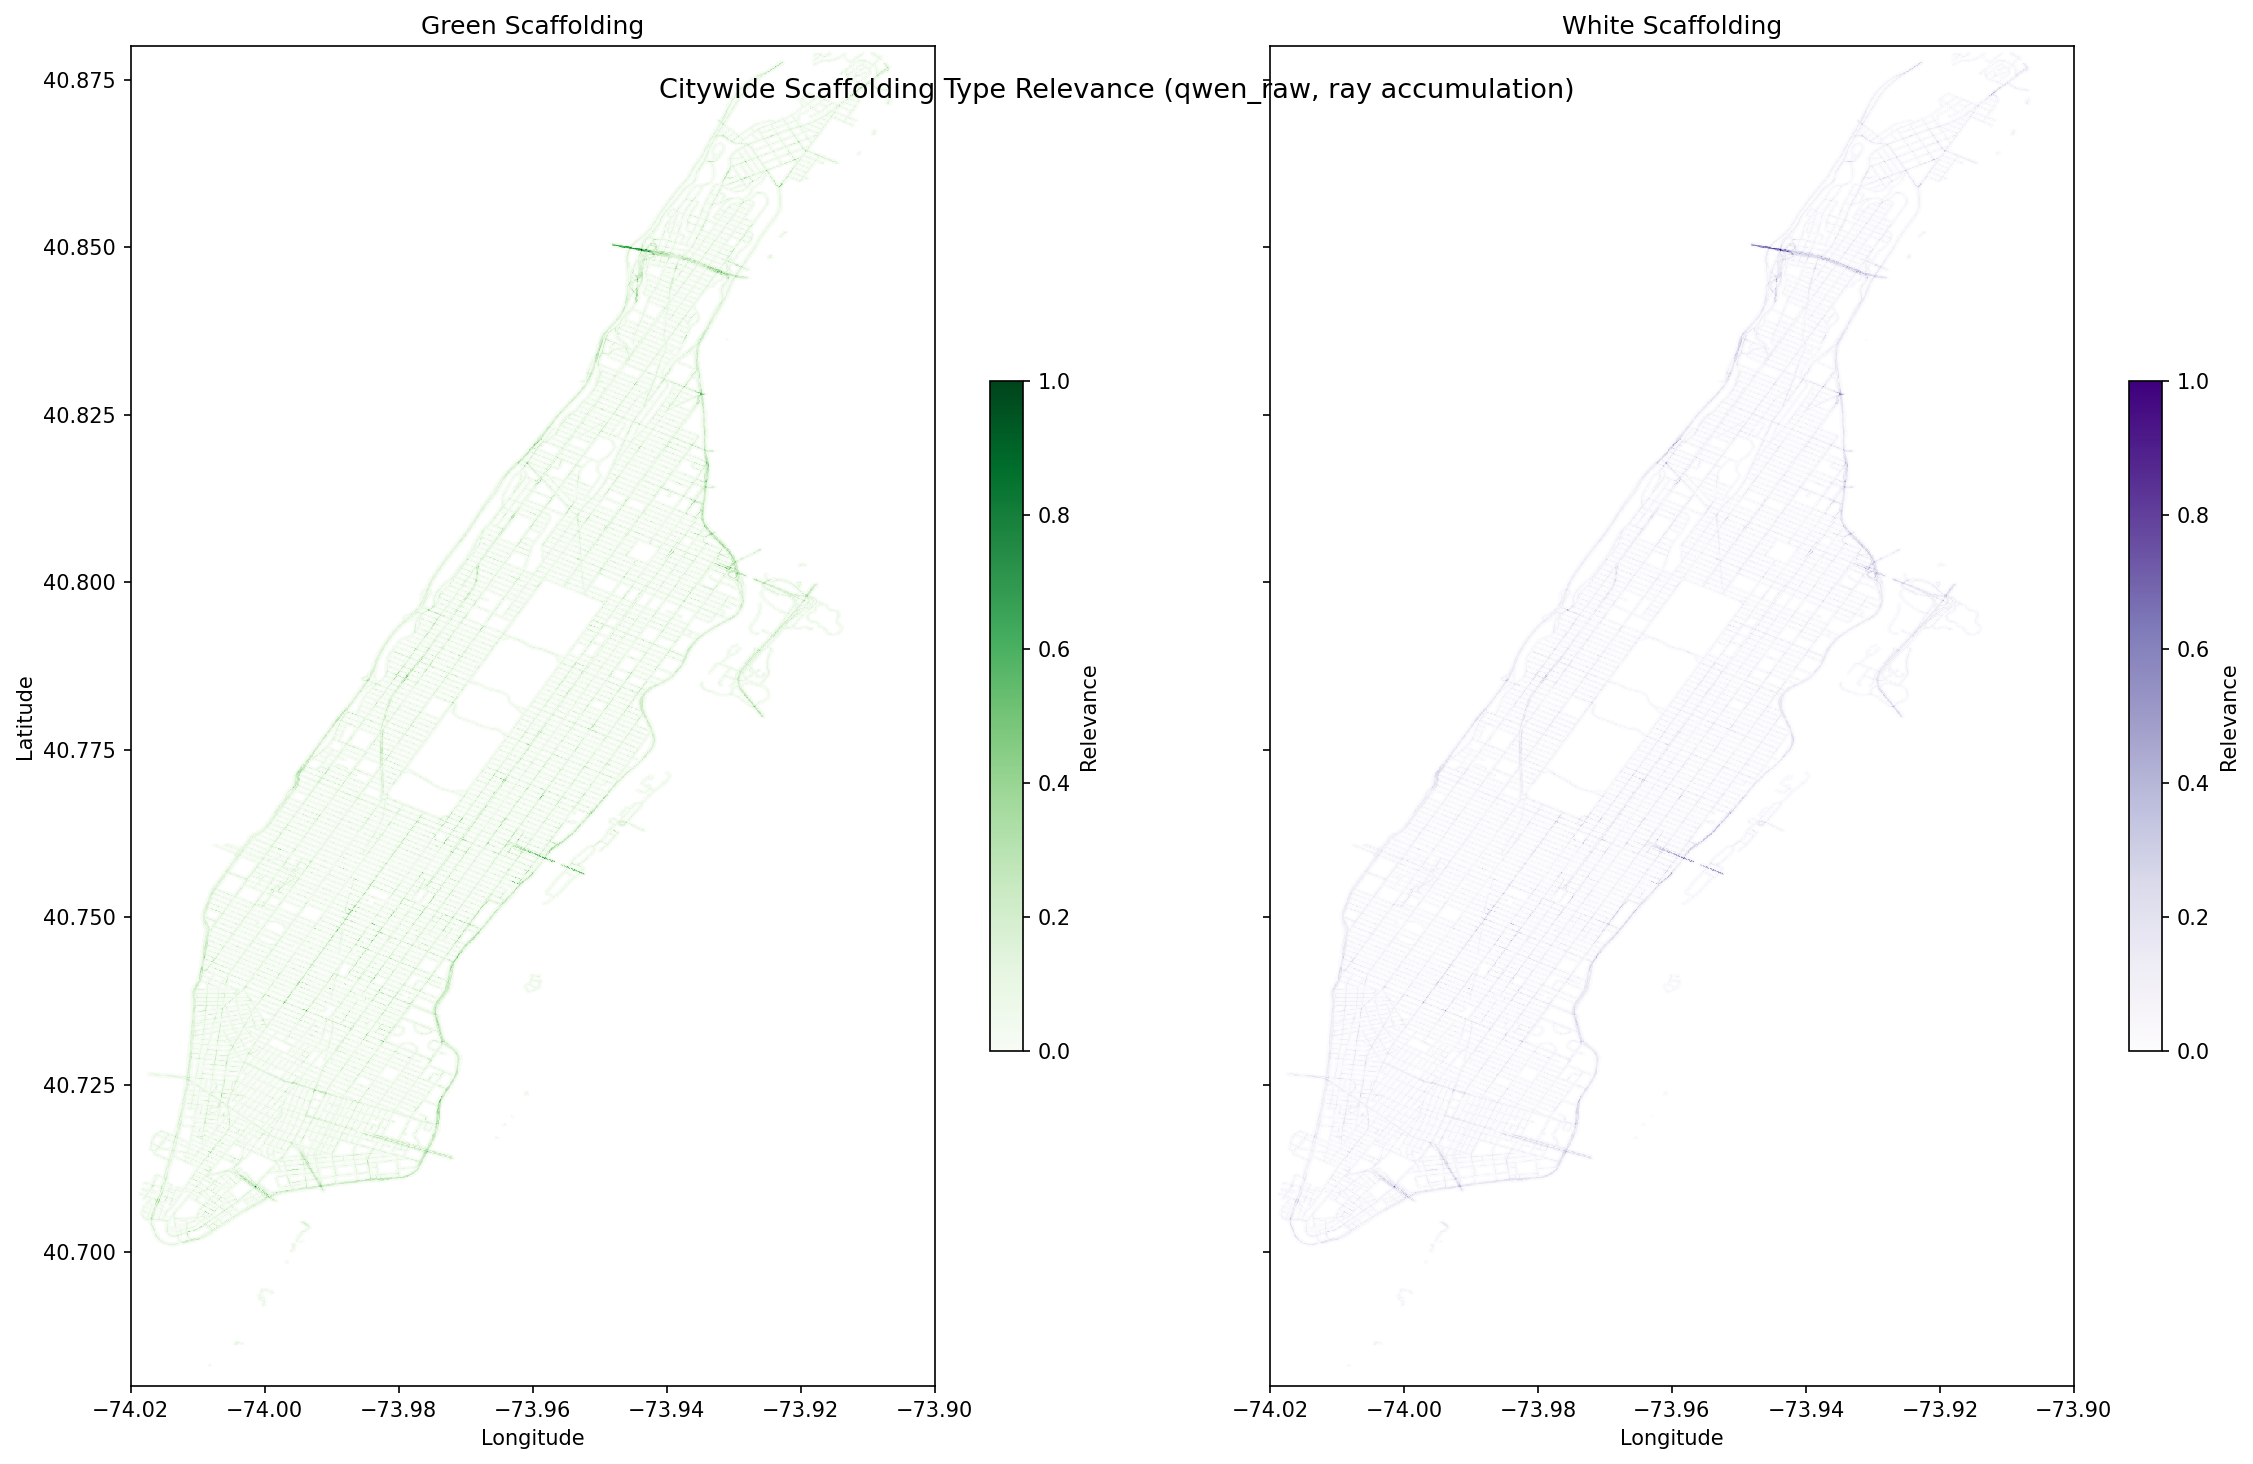

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 10), sharey=True)

for ax, raster, title, cmap in [
    (axes[0], green, "Green Scaffolding", "Greens"),
    (axes[1], white, "White Scaffolding", "Purples"),
]:
    im = ax.imshow(raster, extent=extent, cmap=cmap, vmin=0, vmax=1,
                   origin="upper", interpolation="nearest")
    ax.set_xlabel("Longitude")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label="Relevance", shrink=0.5)

axes[0].set_ylabel("Latitude")
plt.suptitle("Citywide Scaffolding Type Relevance (qwen_raw, ray accumulation)", fontsize=13, y=0.92)
plt.tight_layout()
plt.show()

## 9. Signed Difference Map (Green - White)

Diverging colormap: **green** = green scaffolding dominates, **purple** = white scaffolding dominates, **gray** = no clear winner (ambiguous or absent).

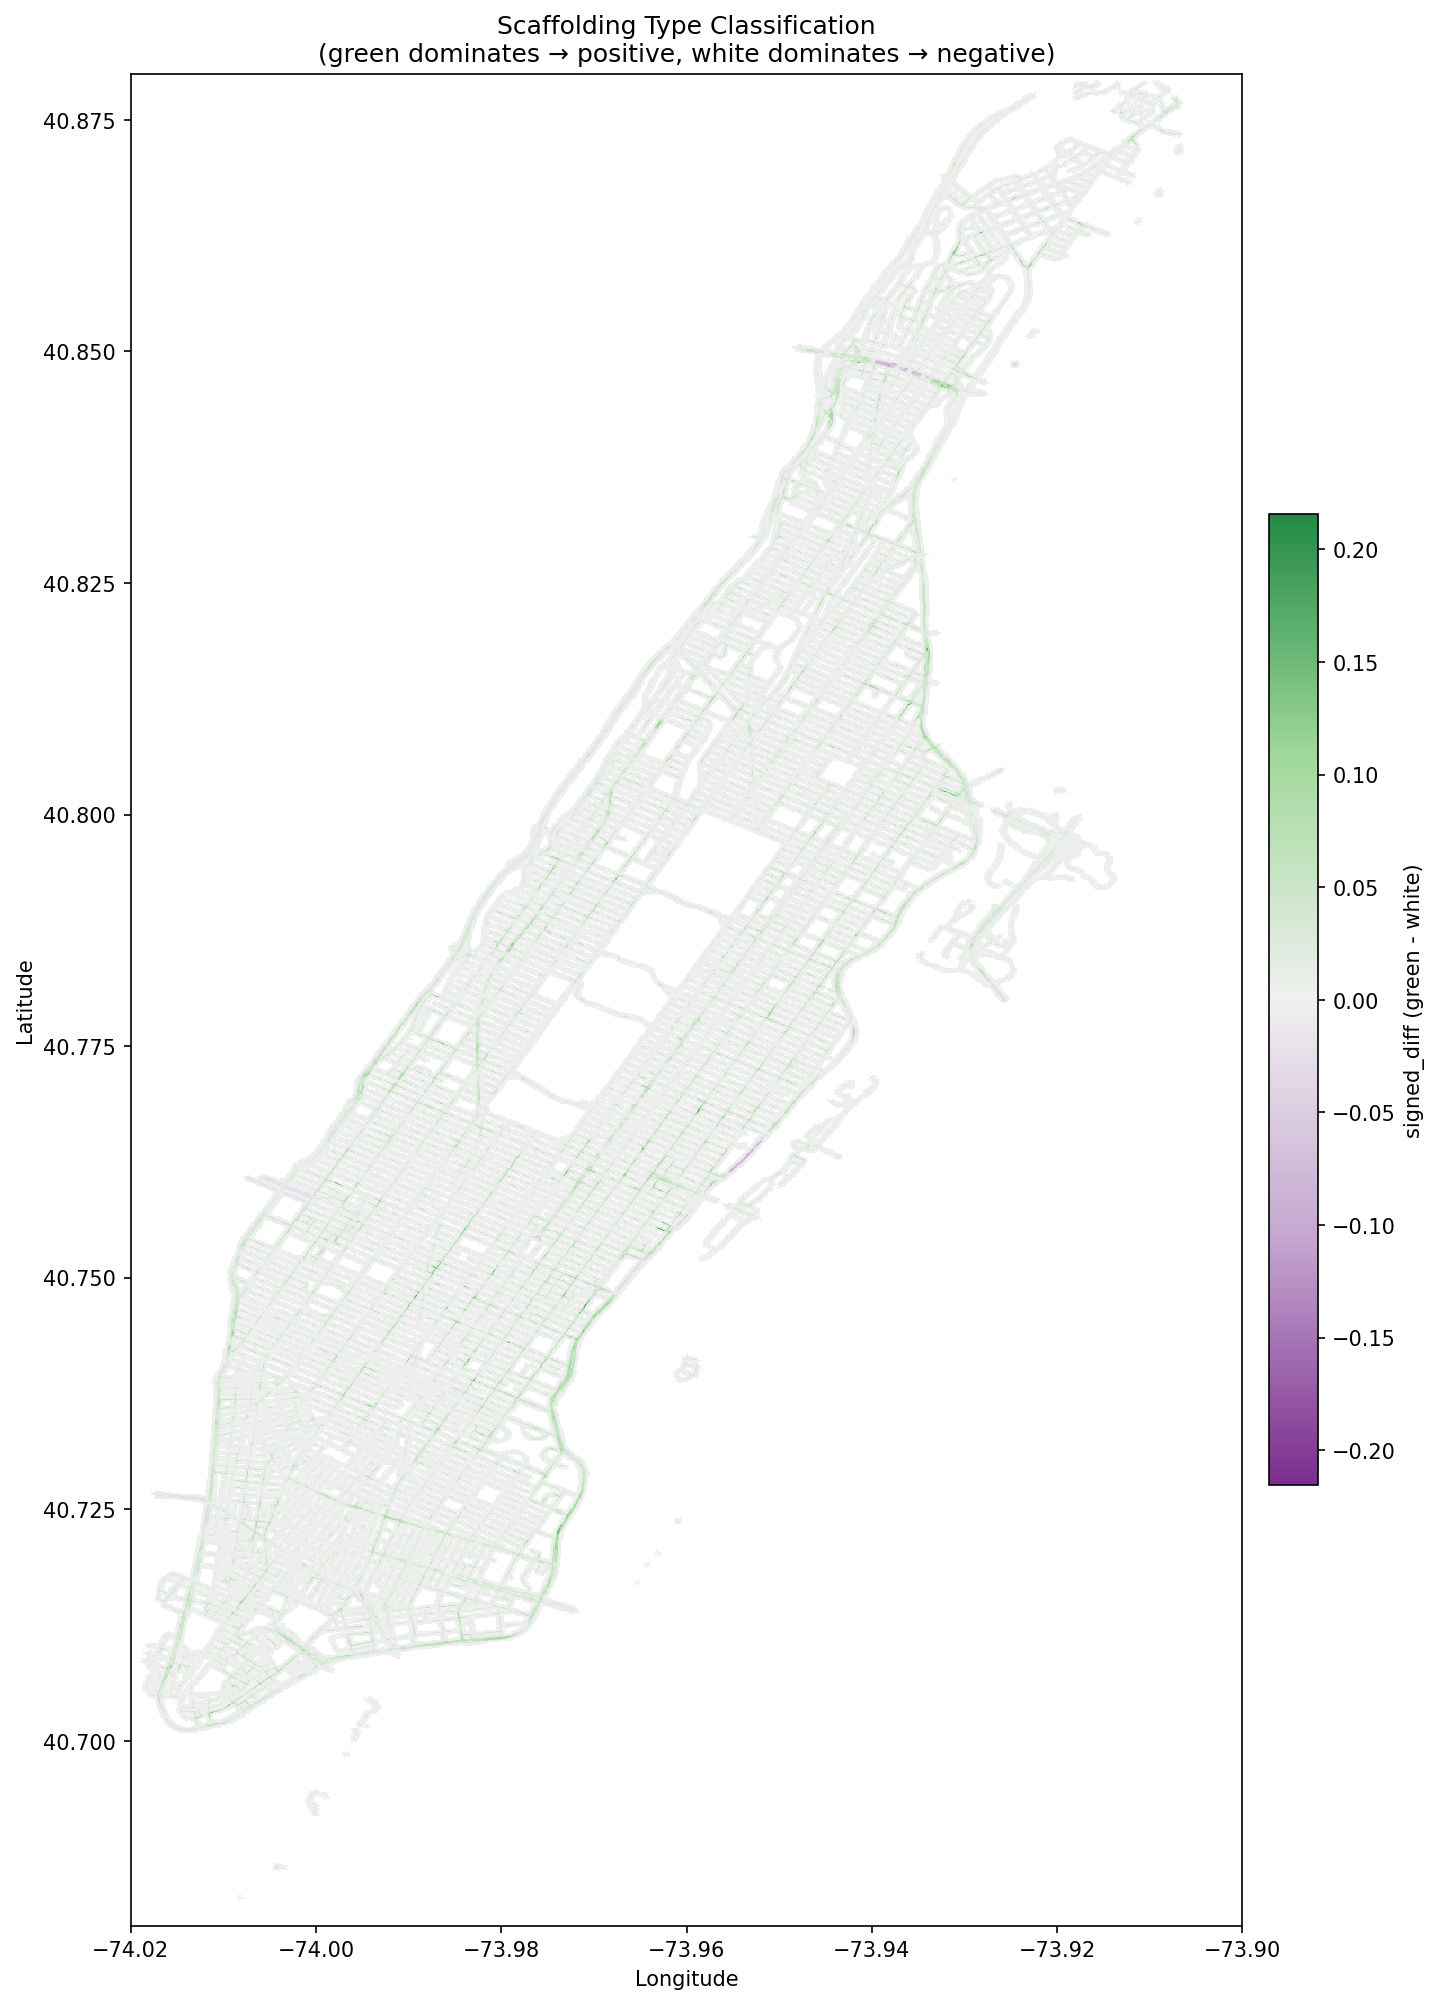

Signed diff stats:
  Mean: 0.00560 (green-leaning)
  Std:  0.01575
  Cells green-dominant (>0): 195803 (42.9%)
  Cells white-dominant (<0): 260377 (57.1%)


In [15]:
# Custom diverging colormap: purple (white scaffolding) ← gray → green (green scaffolding)
from matplotlib.colors import LinearSegmentedColormap

colors_div = ["#7b2d8e", "#c4a5cf", "#f0f0f0", "#a1d99b", "#238b45"]
cmap_div = LinearSegmentedColormap.from_list("green_white_scaffolding", colors_div, N=256)

# Symmetric range for diverging map
sd_valid = signed_diff[np.isfinite(signed_diff)]
vmax_sym = max(abs(sd_valid.min()), abs(sd_valid.max()))

fig, ax = plt.subplots(figsize=(10, 14))
im = ax.imshow(
    signed_diff, extent=extent, cmap=cmap_div,
    vmin=-vmax_sym, vmax=vmax_sym,
    origin="upper", interpolation="nearest",
)
cbar = plt.colorbar(im, ax=ax, label="Green ← → White", shrink=0.5, pad=0.02)
cbar.ax.set_ylabel("signed_diff (green - white)", fontsize=10)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Scaffolding Type Classification\n(green dominates → positive, white dominates → negative)")
plt.tight_layout()
plt.show()

print(f"Signed diff stats:")
print(f"  Mean: {sd_valid.mean():.5f} ({'green-leaning' if sd_valid.mean() > 0 else 'white-leaning'})")
print(f"  Std:  {sd_valid.std():.5f}")
print(f"  Cells green-dominant (>0): {np.sum(sd_valid > 0)} ({100*np.mean(sd_valid > 0):.1f}%)")
print(f"  Cells white-dominant (<0): {np.sum(sd_valid < 0)} ({100*np.mean(sd_valid < 0):.1f}%)")

## 10. Classification Confidence (|Green - White|)

High values = the model is confident about the scaffolding type (either green OR white clearly dominates).
Low values = ambiguous (both score similarly) or no scaffolding at all.

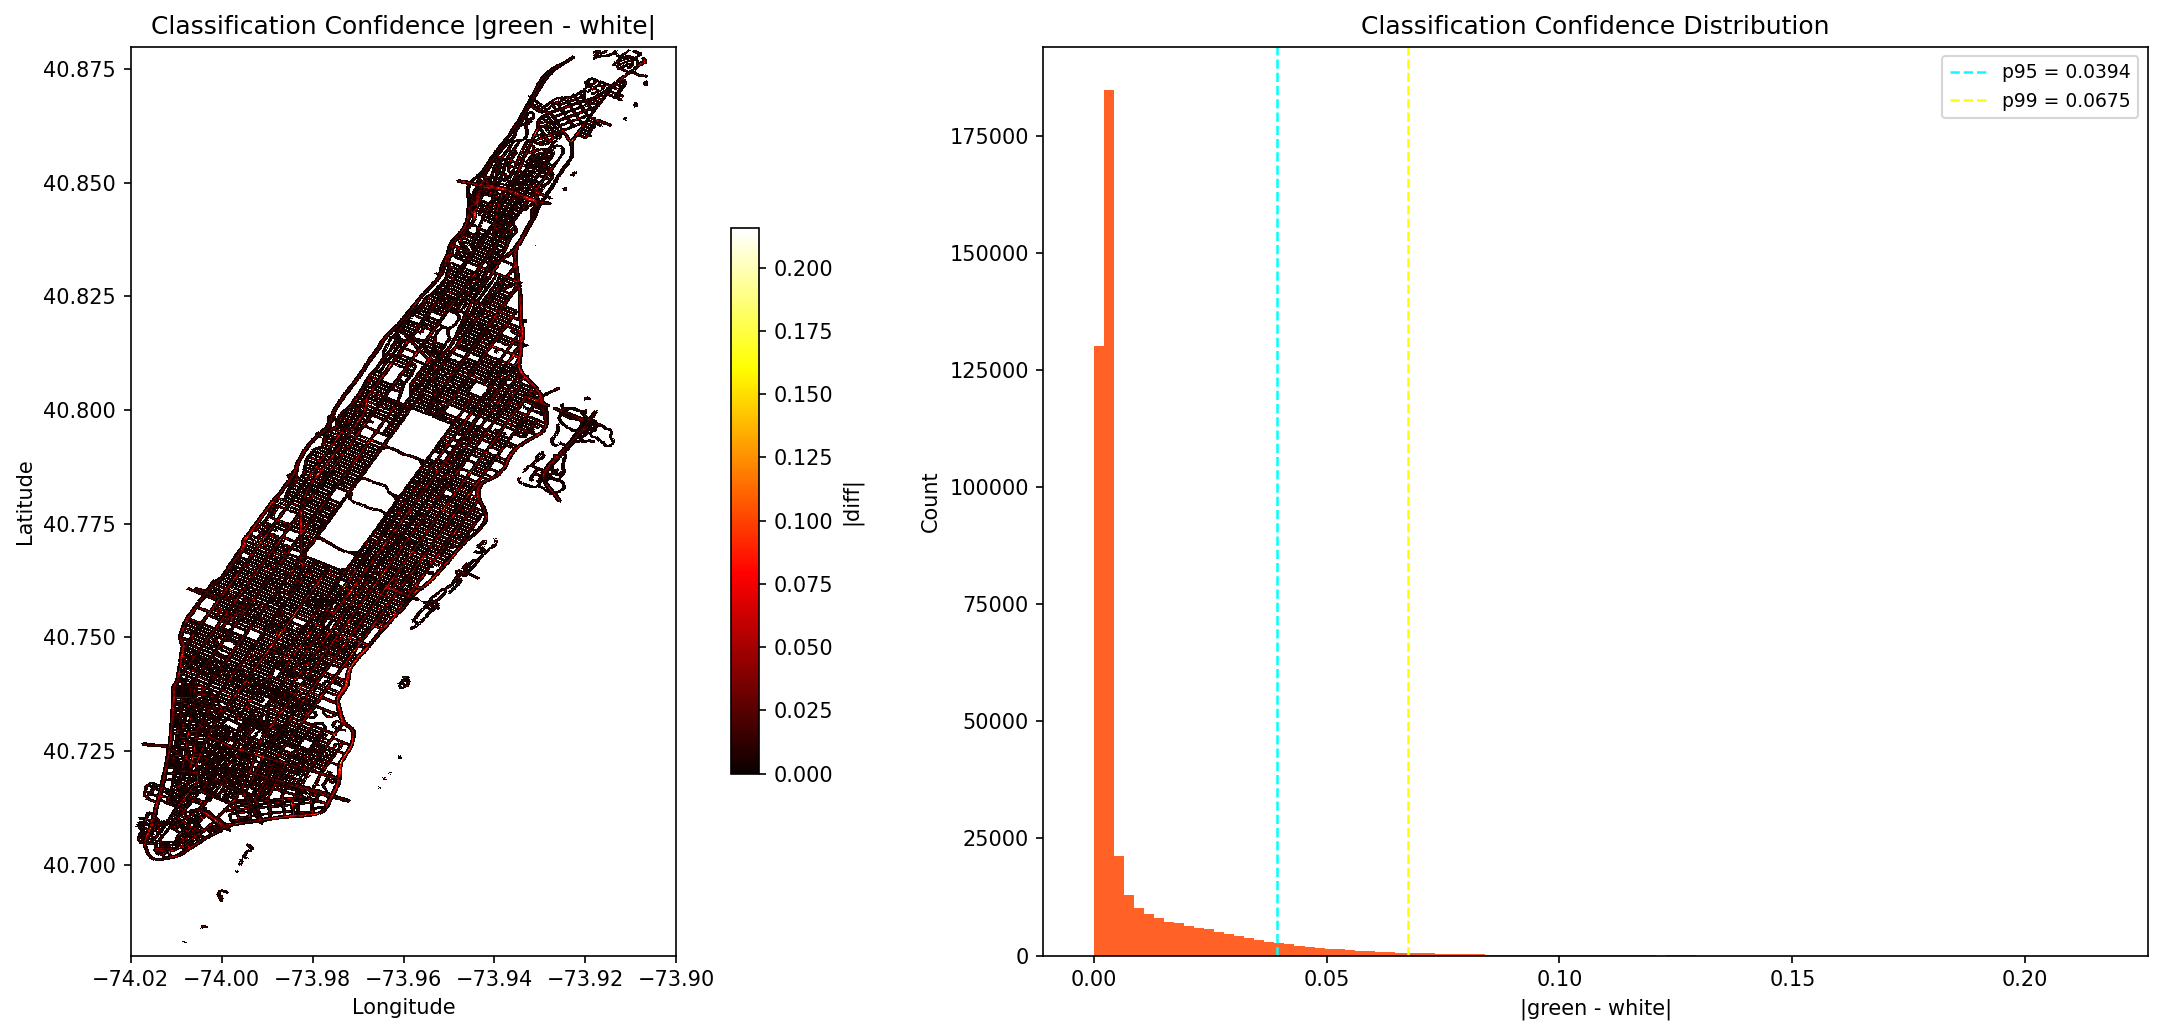

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: abs_diff map
ax = axes[0]
im = ax.imshow(abs_diff, extent=extent, cmap="hot", vmin=0,
               origin="upper", interpolation="nearest")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Classification Confidence |green - white|")
plt.colorbar(im, ax=ax, label="|diff|", shrink=0.6)

# Right: histogram of abs_diff
ax = axes[1]
ad_valid = abs_diff[np.isfinite(abs_diff)]
ax.hist(ad_valid, bins=100, color="orangered", edgecolor="none", alpha=0.85)
ax.axvline(np.percentile(ad_valid, 95), color="cyan", ls="--", lw=1.2,
           label=f"p95 = {np.percentile(ad_valid, 95):.4f}")
ax.axvline(np.percentile(ad_valid, 99), color="yellow", ls="--", lw=1.2,
           label=f"p99 = {np.percentile(ad_valid, 99):.4f}")
ax.set_xlabel("|green - white|")
ax.set_ylabel("Count")
ax.set_title("Classification Confidence Distribution")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 11. Green vs. White Scatter (Pixel-Level)

Each dot is a pixel. Pixels on the diagonal score equally for both types (ambiguous). Pixels far from the diagonal are confidently one type or the other.

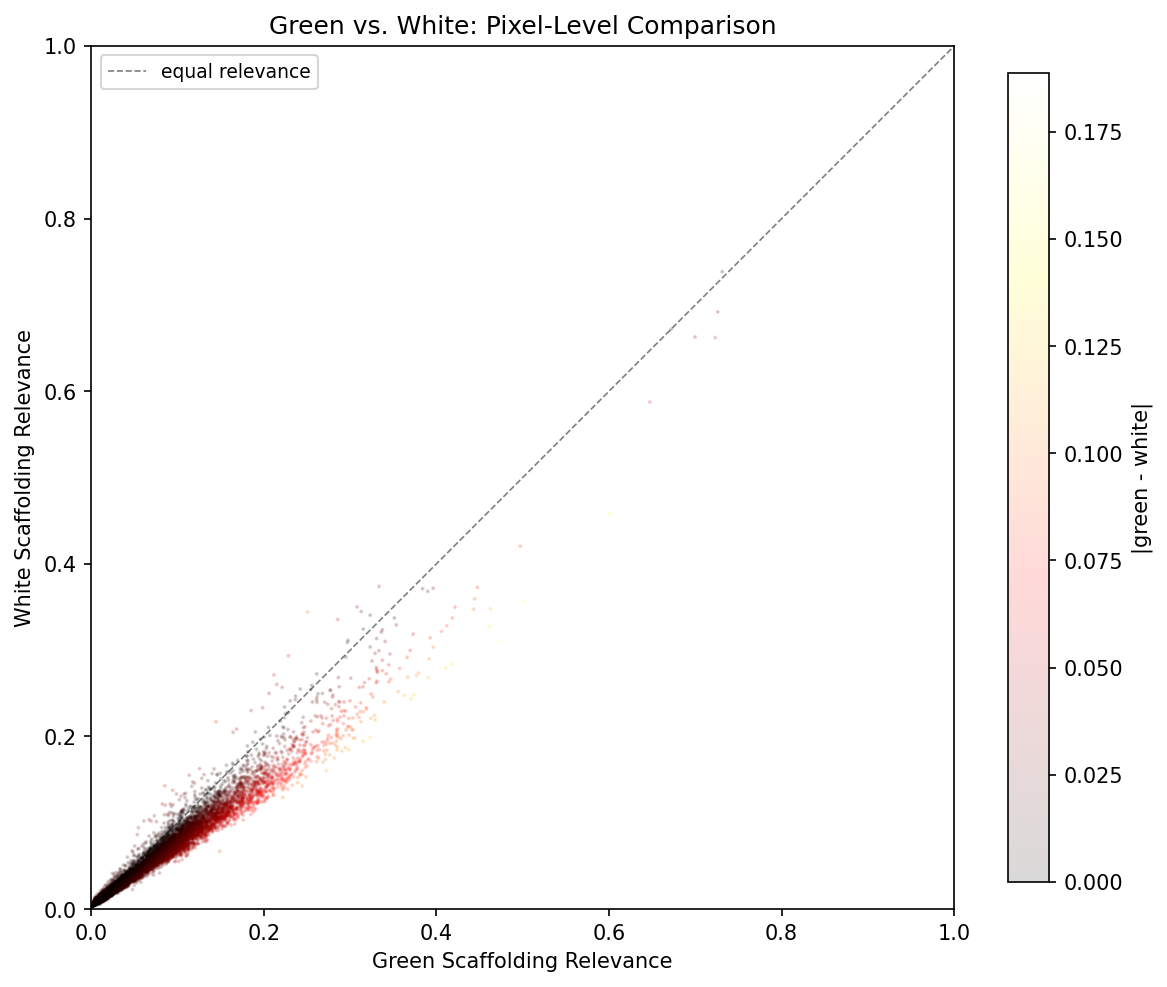

Spearman correlation (green vs white): r = 0.9937, p = 0.00e+00
Pixels above diagonal (green > white): 195803 (42.9%)
Pixels below diagonal (white > green): 260377 (57.1%)


In [17]:
# Pixel-level scatter: green vs white relevance
g_flat = green.ravel()
w_flat = white.ravel()
both_valid = np.isfinite(g_flat) & np.isfinite(w_flat)
gv = g_flat[both_valid]
wv = w_flat[both_valid]

fig, ax = plt.subplots(figsize=(8, 8))

# Subsample for readability
n_sample = min(20000, len(gv))
idx = np.random.default_rng(42).choice(len(gv), n_sample, replace=False)

sc = ax.scatter(gv[idx], wv[idx], s=1, alpha=0.15, c=np.abs(gv[idx] - wv[idx]),
                cmap="hot", vmin=0, rasterized=True)
ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5, label="equal relevance")
ax.set_xlabel("Green Scaffolding Relevance")
ax.set_ylabel("White Scaffolding Relevance")
ax.set_title("Green vs. White: Pixel-Level Comparison")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.legend(fontsize=9, loc="upper left")
plt.colorbar(sc, ax=ax, label="|green - white|", shrink=0.7)
plt.tight_layout()
plt.show()

# Correlation
rho, pval = spearmanr(gv, wv)
print(f"Spearman correlation (green vs white): r = {rho:.4f}, p = {pval:.2e}")
print(f"Pixels above diagonal (green > white): {np.sum(gv > wv)} ({100*np.mean(gv > wv):.1f}%)")
print(f"Pixels below diagonal (white > green): {np.sum(wv > gv)} ({100*np.mean(wv > gv):.1f}%)")

## 12. Tri-Class Segmentation Map

Classify each pixel into one of three categories based on thresholds:
- **Green zone**: signed_diff > threshold (green scaffolding dominates)
- **White zone**: signed_diff < -threshold (white scaffolding dominates)
- **Ambiguous/absent**: |signed_diff| <= threshold

Classification threshold (p90 of |diff|): 0.02675


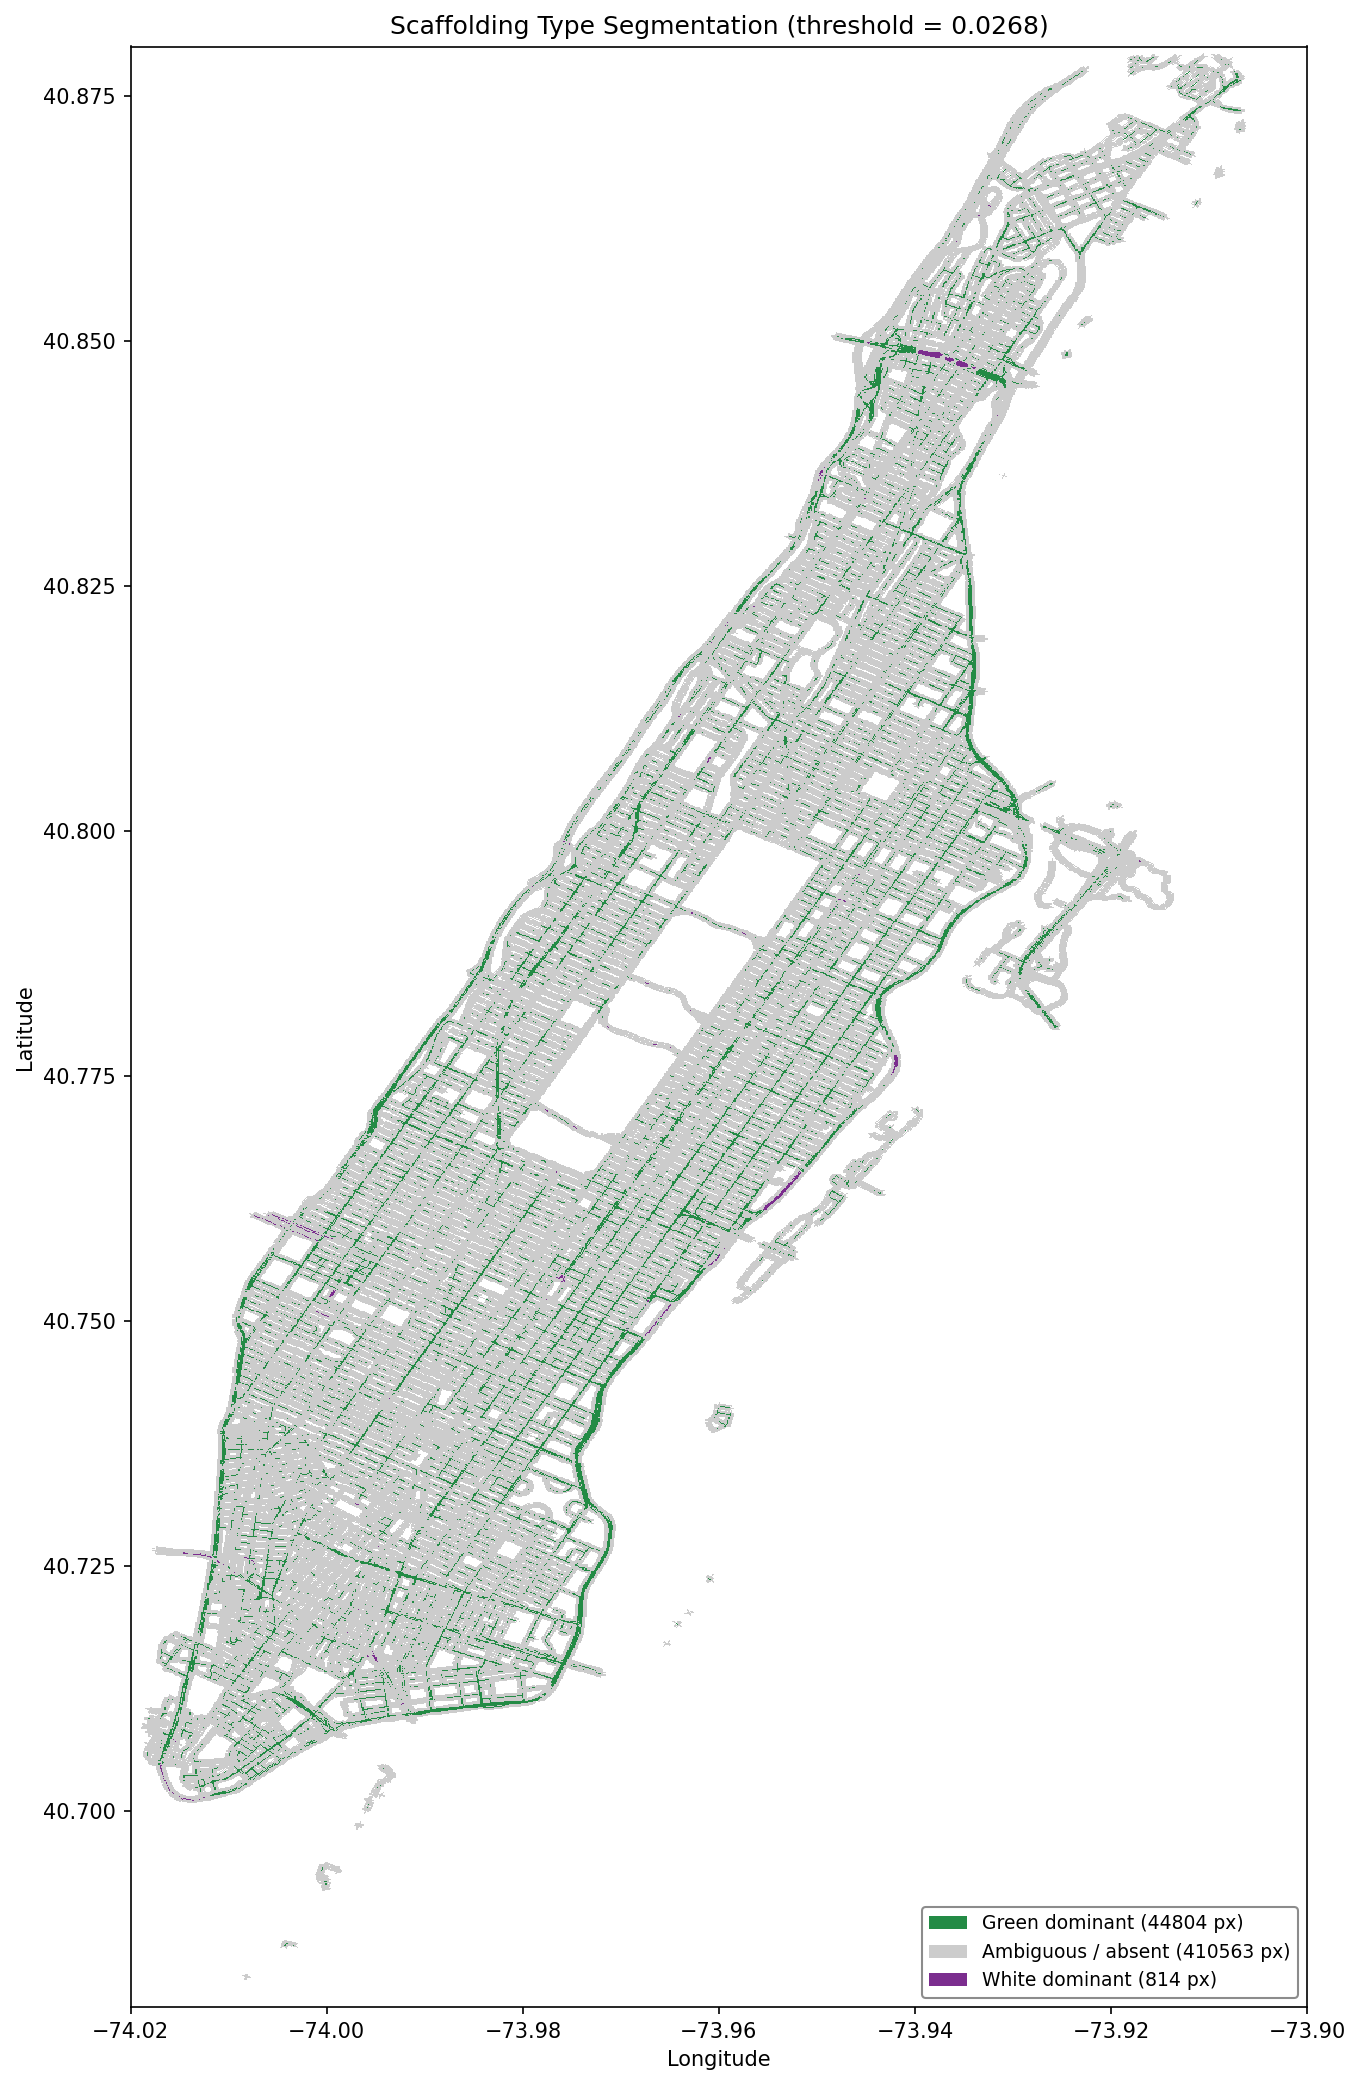

Green:     44,804 pixels (9.8%)
White:     814 pixels (0.2%)
Ambiguous: 410,563 pixels (90.0%)


In [18]:
# Use p90 of abs_diff as the confidence threshold
threshold = np.percentile(ad_valid, 90)
print(f"Classification threshold (p90 of |diff|): {threshold:.5f}")

# Tri-class map: 0=NoData, 1=green, 2=ambiguous, 3=white
triclass = np.full_like(signed_diff, np.nan)
valid_mask = np.isfinite(signed_diff)
triclass[valid_mask & (signed_diff > threshold)] = 1.0   # green
triclass[valid_mask & (np.abs(signed_diff) <= threshold)] = 0.5  # ambiguous
triclass[valid_mask & (signed_diff < -threshold)] = 0.0   # white

cmap_tri = mcolors.ListedColormap(["#7b2d8e", "#cccccc", "#238b45"])
bounds = [0, 0.25, 0.75, 1.0]
norm = mcolors.BoundaryNorm(bounds, cmap_tri.N)

fig, ax = plt.subplots(figsize=(10, 14))
im = ax.imshow(triclass, extent=extent, cmap=cmap_tri, norm=norm,
               origin="upper", interpolation="nearest")

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#238b45", label=f"Green dominant ({np.nansum(triclass == 1.0):.0f} px)"),
    Patch(facecolor="#cccccc", label=f"Ambiguous / absent ({np.nansum(triclass == 0.5):.0f} px)"),
    Patch(facecolor="#7b2d8e", label=f"White dominant ({np.nansum(triclass == 0.0):.0f} px)"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9,
          framealpha=0.9, edgecolor="gray")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Scaffolding Type Segmentation (threshold = {threshold:.4f})")
plt.tight_layout()
plt.show()

n_green = np.nansum(triclass == 1.0)
n_white = np.nansum(triclass == 0.0)
n_ambig = np.nansum(triclass == 0.5)
n_total = n_green + n_white + n_ambig
print(f"Green:     {n_green:,.0f} pixels ({100*n_green/n_total:.1f}%)")
print(f"White:     {n_white:,.0f} pixels ({100*n_white/n_total:.1f}%)")
print(f"Ambiguous: {n_ambig:,.0f} pixels ({100*n_ambig/n_total:.1f}%)")

In [19]:
# Cleanup
for s in [src_green, src_white, src_signed, src_abs]:
    s.close()